In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

# Step 1: Use glob to find all files matching the pattern '*/final_results.csv'
#main_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/temp/simulations/oct19"

main_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/temp/simulations/oct23"

file_paths = glob.glob(os.path.join(main_path, '*/final_results.csv'))

# Check if file paths are found correctly
print(f"Found {len(file_paths)} files.")

# Step 2: Read all CSV files into a list of dataframes
dataframes = [pd.read_csv(file) for file in file_paths]

# Step 3: Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

Found 48 files.


In [2]:
combined_df.head()

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff_albf,correlation_diff_delta,...,optimal_threshold,accuracy,precision,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,input_conc.1
0,0.9,2,False,812.9182,0.1,0.815994,0.815994,0.815994,0.503247,0.502189,...,0.482270,0.970115,0.691244,0.994318,469,6,0.900052,NaN,0.000070,812.9182
1,0.5,17,False,inf,0.1,0.718875,0.718875,0.718875,0.840858,0.640518,...,1.520001,0.928688,0.904275,0.945992,712,384,0.794125,cell_ontology_class,0.069613,inf
2,0.9,17,False,inf,0.1,0.729954,0.729954,0.729954,0.515657,0.422081,...,0.995109,0.968573,0.757659,0.971930,443,40,0.593030,cell_ontology_class,-0.002568,inf
3,0.9,17,True,inf,0.1,0.386227,0.386227,0.386227,0.498423,0.279829,...,0.829807,0.917041,0.528824,0.965614,1226,49,0.055613,cell_ontology_class,0.000982,inf
4,0.5,2,True,inf,0.1,0.989184,0.989184,0.989184,0.874779,0.890623,...,1.405776,0.899836,0.788043,0.966648,1411,181,0.919650,NaN,0.000664,inf


In [3]:
# Remove the extra input_conc column
combined_df = combined_df.drop(columns=["input_conc.1"])

In [4]:
combined_df['junc_prior'] = combined_df['use_global_prior'].replace({False: "NO", True: "YES"})

In [5]:
combined_df

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff_albf,correlation_diff_delta,...,optimal_threshold,accuracy,precision,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,junc_prior
0,0.9,2,False,812.918200,0.1,0.815994,0.815994,0.815994,0.503247,0.502189,...,0.482270,0.970115,0.691244,0.994318,469,6,0.900052,NaN,7.023641e-05,NO
1,0.5,17,False,inf,0.1,0.718875,0.718875,0.718875,0.840858,0.640518,...,1.520001,0.928688,0.904275,0.945992,712,384,0.794125,cell_ontology_class,6.961260e-02,NO
2,0.9,17,False,inf,0.1,0.729954,0.729954,0.729954,0.515657,0.422081,...,0.995109,0.968573,0.757659,0.971930,443,40,0.593030,cell_ontology_class,-2.567935e-03,NO
3,0.9,17,True,inf,0.1,0.386227,0.386227,0.386227,0.498423,0.279829,...,0.829807,0.917041,0.528824,0.965614,1226,49,0.055613,cell_ontology_class,9.817927e-04,YES
4,0.5,2,True,inf,0.1,0.989184,0.989184,0.989184,0.874779,0.890623,...,1.405776,0.899836,0.788043,0.966648,1411,181,0.919650,NaN,6.644669e-04,YES
5,0.5,2,False,inf,0.1,0.997865,0.997865,0.997865,0.898303,0.922116,...,1.125799,0.921731,0.822583,0.982087,1147,97,0.957769,NaN,-2.703284e-05,NO
6,0.1,2,False,3464.271000,0.1,0.999109,0.999109,0.999109,0.865883,0.996128,...,3.353720,0.859821,0.877418,0.893798,1204,1024,0.974333,NaN,2.805821e-01,NO
7,0.1,2,False,inf,0.1,0.998974,0.998974,0.998974,0.868410,0.996378,...,2.982437,0.862212,0.865872,0.912088,1350,840,0.973921,NaN,3.010717e-01,NO
8,0.9,2,True,28.071976,0.1,0.985592,0.985592,0.985592,0.490757,0.485839,...,0.328930,0.945451,0.560000,0.991826,858,9,0.868209,NaN,-3.970548e-05,YES
9,0.9,17,True,42.796772,0.1,0.594687,0.594687,0.594687,0.485565,0.131801,...,0.401557,0.906825,0.498712,0.950877,1362,70,0.261381,cell_ontology_class,-5.643217e-02,YES


In [6]:
# Create new likelihood column based on input_conc
combined_df["Likelihood"] = combined_df["input_conc"].apply(lambda x: "Binomial" if x == float('inf') else "Beta-Binomial")
combined_df

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff_albf,correlation_diff_delta,...,accuracy,precision,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,junc_prior,Likelihood
0,0.9,2,False,812.918200,0.1,0.815994,0.815994,0.815994,0.503247,0.502189,...,0.970115,0.691244,0.994318,469,6,0.900052,NaN,7.023641e-05,NO,Beta-Binomial
1,0.5,17,False,inf,0.1,0.718875,0.718875,0.718875,0.840858,0.640518,...,0.928688,0.904275,0.945992,712,384,0.794125,cell_ontology_class,6.961260e-02,NO,Binomial
2,0.9,17,False,inf,0.1,0.729954,0.729954,0.729954,0.515657,0.422081,...,0.968573,0.757659,0.971930,443,40,0.593030,cell_ontology_class,-2.567935e-03,NO,Binomial
3,0.9,17,True,inf,0.1,0.386227,0.386227,0.386227,0.498423,0.279829,...,0.917041,0.528824,0.965614,1226,49,0.055613,cell_ontology_class,9.817927e-04,YES,Binomial
4,0.5,2,True,inf,0.1,0.989184,0.989184,0.989184,0.874779,0.890623,...,0.899836,0.788043,0.966648,1411,181,0.919650,NaN,6.644669e-04,YES,Binomial
5,0.5,2,False,inf,0.1,0.997865,0.997865,0.997865,0.898303,0.922116,...,0.921731,0.822583,0.982087,1147,97,0.957769,NaN,-2.703284e-05,NO,Binomial
6,0.1,2,False,3464.271000,0.1,0.999109,0.999109,0.999109,0.865883,0.996128,...,0.859821,0.877418,0.893798,1204,1024,0.974333,NaN,2.805821e-01,NO,Beta-Binomial
7,0.1,2,False,inf,0.1,0.998974,0.998974,0.998974,0.868410,0.996378,...,0.862212,0.865872,0.912088,1350,840,0.973921,NaN,3.010717e-01,NO,Binomial
8,0.9,2,True,28.071976,0.1,0.985592,0.985592,0.985592,0.490757,0.485839,...,0.945451,0.560000,0.991826,858,9,0.868209,NaN,-3.970548e-05,YES,Beta-Binomial
9,0.9,17,True,42.796772,0.1,0.594687,0.594687,0.594687,0.485565,0.131801,...,0.906825,0.498712,0.950877,1362,70,0.261381,cell_ontology_class,-5.643217e-02,YES,Beta-Binomial


In [7]:
combined_df['combined_prior_input'] = combined_df['use_global_prior'].astype(str) + '-' + combined_df['Likelihood']

In [8]:
nmf_vs_model = combined_df[["silhouette_NMF", "silhouette_avg", "K", "proportion_negative"]]
# Melt the DataFrame
df_melted = pd.melt(nmf_vs_model, id_vars=['K', 'proportion_negative'], 
                    value_vars=['silhouette_NMF', 'silhouette_avg'], 
                    var_name='model', value_name='silhouette_value')

# Rename 'model' values to 'NMF' and 'Leaflet-FA'
df_melted['model'] = df_melted['model'].replace({
    'silhouette_NMF': 'NMF',
    'silhouette_avg': 'Leaflet-FA'
})

# Print the melted DataFrame
print(df_melted)

     K  proportion_negative       model  silhouette_value
0    2                  0.9         NMF          0.000070
1   17                  0.5         NMF          0.069613
2   17                  0.9         NMF         -0.002568
3   17                  0.9         NMF          0.000982
4    2                  0.5         NMF          0.000664
..  ..                  ...         ...               ...
91  17                  0.5  Leaflet-FA          0.525124
92  17                  0.9  Leaflet-FA          0.295058
93   2                  0.1  Leaflet-FA          0.967527
94   2                  0.9  Leaflet-FA          0.894848
95   2                  0.1  Leaflet-FA          0.948333

[96 rows x 4 columns]


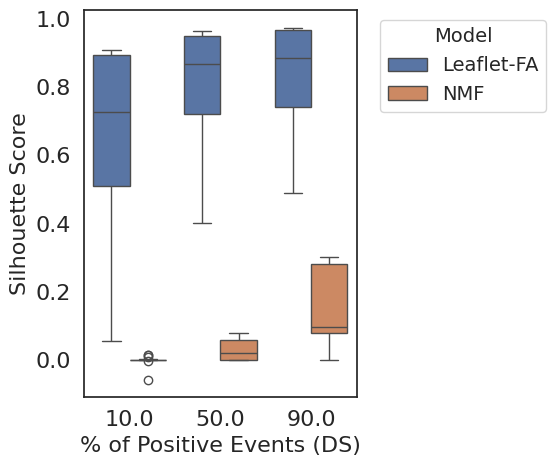

In [9]:
df_melted["prop_positive"] = (1 - df_melted["proportion_negative"]).round(1) * 100 
df_melted.sort_values(by="model", inplace=True)

# Create a figure with a specified size
plt.figure(figsize=(6, 5))

# Create the boxplot
sns.boxplot(data=df_melted, x="prop_positive", y="silhouette_value", hue="model")

# Set x and y axis labels with increased font size
plt.xlabel('% of Positive Events (DS)', fontsize=16)
plt.ylabel('Silhouette Score', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Move the legend outside the plot and increase its font size
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=14)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

plt.savefig('simulation_NMF_vs_Leaflet.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()

In [10]:
combined_df["prop_positive"] = (1 - combined_df["proportion_negative"]).round(1) * 100 


In [11]:
!pwd

/gpfs/commons/home/kisaev/Leaflet-private/analysis/simulation


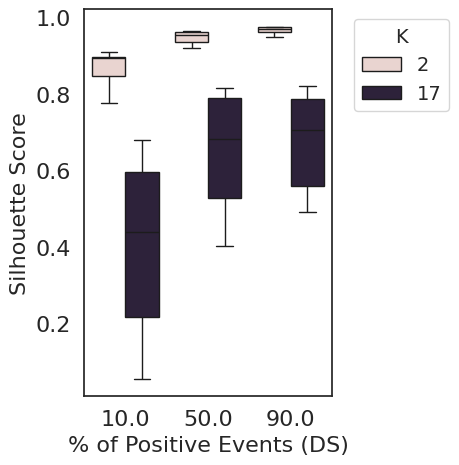

In [12]:
# Create a figure with a specified size
plt.figure(figsize=(5, 5))

# Create the boxplot
sns.boxplot(data=combined_df, x="prop_positive", y="silhouette_avg", hue="K")

# Set x and y axis labels with increased font size
plt.xlabel('% of Positive Events (DS)', fontsize=16)
plt.ylabel('Silhouette Score', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Move the legend outside the plot and increase its font size
plt.legend(title="K", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=14)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

plt.savefig('simulation_positive_events_vs_ss.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()

/scratch/ipykernel_248321/64340187.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  k2.sort_values(by="Likelihood", inplace=True)


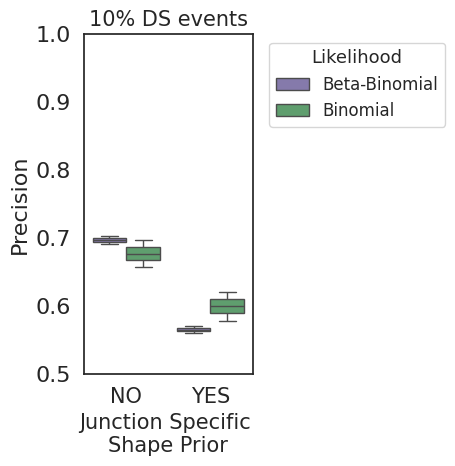

In [14]:
k2 = combined_df[combined_df["K"] == 2]
k2.sort_values(by="Likelihood", inplace=True)

# Define a custom palette for Likelihood values
custom_palette = {
    "Binomial": sns.color_palette("deep")[2],  # Third color in the 'deep' palette
    "Beta-Binomial": sns.color_palette("deep")[4]  # Fourth color in the 'deep' palette
}

# Create a figure with a specified size
plt.figure(figsize=(5, 5))

# Create the boxplot
sns.boxplot(data=k2[k2["prop_positive"] == 10.0], x="junc_prior", y="precision", hue="Likelihood", palette=custom_palette)

# Set x and y axis labels with increased font size
plt.xlabel("Junction Specific \nShape Prior", fontsize=15)
plt.ylabel('Precision', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=15)
plt.yticks(fontsize=16)

plt.ylim(0.5, 1)

plt.title('10% DS events', fontsize=15)

# Move the legend outside the plot and increase its font size
plt.legend(title="Likelihood", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()
plt.savefig('simulations_10perc_likelihood_precision.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()

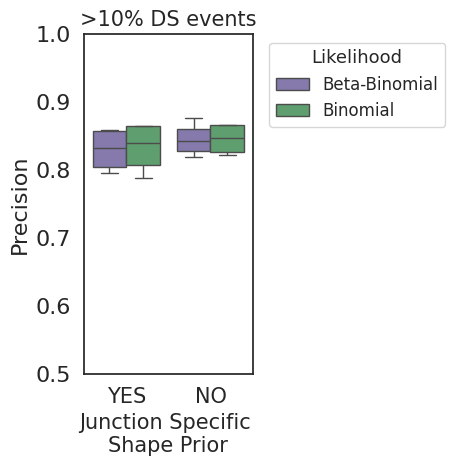

In [15]:
# Create a figure with a specified size
plt.figure(figsize=(5, 5))

# Create the boxplot
sns.boxplot(data=k2[k2["prop_positive"] > 10.0], x="junc_prior", y="precision", hue="Likelihood", palette=custom_palette)

# Set x and y axis labels with increased font size
plt.xlabel("Junction Specific \nShape Prior", fontsize=15)
plt.ylabel('Precision', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=15)
plt.yticks(fontsize=16)

plt.ylim(0.5, 1)

plt.title('>10% DS events', fontsize=15)

# Move the legend outside the plot and increase its font size
plt.legend(title="Likelihood", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()
plt.savefig('simulations_morethan10perc_likelihood_precision.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()

In [16]:
k2.columns

Index(['proportion_negative', 'K', 'use_global_prior', 'input_conc',
       'learning_rate', 'avg_corr', 'median_corr', 'min_corr',
       'correlation_diff_albf', 'correlation_diff_delta', 'auc_score',
       'optimal_threshold', 'accuracy', 'precision', 'recall',
       'false_positives', 'false_negatives', 'silhouette_avg',
       'cell_type_column', 'silhouette_NMF', 'junc_prior', 'Likelihood',
       'combined_prior_input', 'prop_positive'],
      dtype='object')

In [17]:
k2.sort_values(by="correlation_diff_delta")

,proportion_negative,K,use_global_prior,input_conc,learning_rate,avg_corr,median_corr,min_corr,correlation_diff_albf,correlation_diff_delta,...,recall,false_positives,false_negatives,silhouette_avg,cell_type_column,silhouette_NMF,junc_prior,Likelihood,combined_prior_input,prop_positive
46,0.9,2,True,36.308235,0.1,0.989556,0.989556,0.989556,0.487160,0.483122,...,0.985380,760,15,0.894848,NaN,8.201317e-06,YES,Beta-Binomial,True-Beta-Binomial,10.0
13,0.9,2,True,inf,0.1,0.922806,0.922806,0.922806,0.490830,0.483831,...,0.990766,654,10,0.774255,NaN,-1.176777e-05,YES,Binomial,True-Binomial,10.0
8,0.9,2,True,28.071976,0.1,0.985592,0.985592,0.985592,0.490757,0.485839,...,0.991826,858,9,0.868209,NaN,-3.970548e-05,YES,Beta-Binomial,True-Beta-Binomial,10.0
22,0.9,2,True,inf,0.1,0.754868,0.754868,0.754868,0.490408,0.486933,...,0.987250,790,14,0.774616,NaN,-9.602366e-05,YES,Binomial,True-Binomial,10.0
30,0.9,2,False,inf,0.1,0.983188,0.983188,0.983188,0.496180,0.499540,...,0.994934,426,5,0.893469,NaN,-1.854128e-05,NO,Binomial,False-Binomial,10.0
24,0.9,2,False,inf,0.1,0.610235,0.610235,0.610235,0.496109,0.500706,...,0.998143,561,2,0.895418,NaN,1.750033e-07,NO,Binomial,False-Binomial,10.0
16,0.9,2,False,471.098300,0.1,0.993331,0.993331,0.993331,0.499375,0.501785,...,0.993843,478,7,0.907474,NaN,4.774806e-05,NO,Beta-Binomial,False-Beta-Binomial,10.0
0,0.9,2,False,812.918200,0.1,0.815994,0.815994,0.815994,0.503247,0.502189,...,0.994318,469,6,0.900052,NaN,7.023641e-05,NO,Beta-Binomial,False-Beta-Binomial,10.0
26,0.5,2,True,25.415144,0.1,0.998509,0.998509,0.998509,0.871385,0.879338,...,0.965155,1338,189,0.937589,NaN,6.863900e-04,YES,Beta-Binomial,True-Beta-Binomial,50.0
38,0.5,2,True,31.580023,0.1,0.997652,0.997652,0.997652,0.875332,0.889082,...,0.962100,1236,205,0.947565,NaN,5.545785e-05,YES,Beta-Binomial,True-Beta-Binomial,50.0


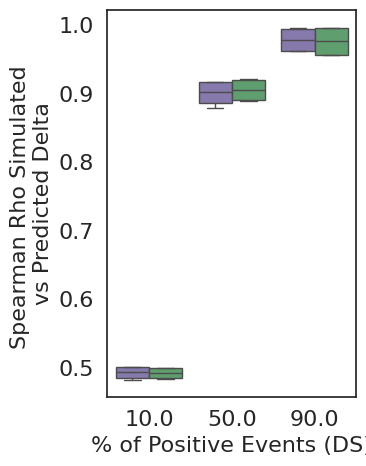

In [22]:
# Create a figure with a specified size
plt.figure(figsize=(4, 5))

# Create the boxplot
sns.boxplot(data=k2, x="prop_positive", y="correlation_diff_delta", hue="Likelihood", palette=custom_palette, legend=False)

# Set x and y axis labels with increased font size
plt.xlabel("% of Positive Events (DS)", fontsize=16)
plt.ylabel('Spearman Rho Simulated \nvs Predicted Delta', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Move the legend outside the plot and increase its font size
# plt.legend(title="Likelihood", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

plt.savefig('simulations_delta_psi_leafletfa.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(x='combined_prior_input', y='silhouette_avg', hue='combined_prior_input', data=k2)
plt.title("Simulated junction counts with K = 2")
plt.xticks(rotation=45)  # Rotates the x-axis labels by 45 degrees
plt.show()

In [ ]:
# plot silouette average across different K values 
plt.figure(figsize=(6,6))
sns.boxplot(x='proportion_negative', y='silhouette_avg', hue='proportion_negative', data=k2)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 2")

In [ ]:
# plot silouette average across different K values 
k17 = combined_df[combined_df["K"] == 17]
plt.figure(figsize=(6,6))
sns.boxplot(x='proportion_negative', y='silhouette_avg', hue='proportion_negative', data=k17)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 17 \n(based on real cell type labels)")

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(x='combined_prior_input', y='silhouette_avg', hue='combined_prior_input', data=k17)
plt.ylim(0, 1)
plt.title("Simulated junction counts with K = 17 \n(based on real cell type labels)")
plt.xticks(rotation=45)  # Rotates the x-axis labels by 45 degrees
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font size for all elements
plt.rcParams.update({
    'axes.titlesize': 14,    # Title font size
    'axes.labelsize': 12,    # Axis label font size
    'xtick.labelsize': 10,   # X-axis tick label font size
    'ytick.labelsize': 10,   # Y-axis tick label font size
    'legend.fontsize': 12    # Legend font size
})

# Step 1: Filter the dataframe to include only K=2
df_k2 = combined_df[combined_df['K'] == 2]

# Precision 
plt.figure(figsize=(6, 4))  # Adjust figure size to make it smaller
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k2)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k2)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


In [ ]:
# Step 1: Filter the dataframe to include only K=17
df_k17 = combined_df[combined_df['K'] == 17]

# Precision 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='precision', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# False Positive Rate (using false positives directly)
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='false_positives', hue='proportion_negative', data=df_k17)
plt.ylabel('False Positives (Proxy for FPR)')
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='accuracy', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()

# Recall 
plt.figure(figsize=(6, 4))
sns.barplot(x='combined_prior_input', y='recall', hue='proportion_negative', data=df_k17)
plt.xticks(rotation=45)  # Rotate x-axis tick labels
plt.show()


In [ ]:
# Across different Ks, combined_prior_input and prop negative, let's summarize avg_corr across inits, silouette score

# Step 1: Group the dataframe by K, combined_prior_input, and proportion_negative
grouped_summary = combined_df.groupby(['K', 'combined_prior_input', 'proportion_negative']).agg(
    avg_corr_mean=('avg_corr', 'mean'),
    silhouette_avg_mean=('silhouette_avg', 'mean')
).reset_index()

In [ ]:
# Filter for proportion_negative = 0.5
grouped_0_5 = grouped_summary[grouped_summary['proportion_negative'] == 0.5]

# Filter for proportion_negative = 0.99
grouped_0_99 = grouped_summary[grouped_summary['proportion_negative'] == 0.9]

# Plot for proportion_negative = 0.5
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='silhouette_avg_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Silhouette Score by K and Combined Prior/Input (Proportion Negative = 0.9)')
plt.show()


In [ ]:
# Plot for proportion_negative = 0.5 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_5, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.5)')
plt.show()

# Plot for proportion_negative = 0.99 (avg_corr_mean)
plt.figure(figsize=(12, 6))
sns.barplot(x='K', y='avg_corr_mean', hue='combined_prior_input', data=grouped_0_99, ci=None)
plt.title('Average Correlation by K and Combined Prior/Input (Proportion Negative = 0.99)')
plt.show()


In [ ]:
k17 = combined_df[combined_df["K"] == 17].sort_values(by="Likelihood")

In [ ]:
k17

In [ ]:
# Create a figure with a specified size
plt.figure(figsize=(5, 5))

# Create the boxplot
sns.boxplot(data=k17[k17["prop_positive"] > 10.0], x="junc_prior", y="silhouette_avg", hue="Likelihood", palette=custom_palette)

# Set x and y axis labels with increased font size
plt.xlabel("Junction Specific \nShape Prior", fontsize=15)
plt.ylabel('Silhouette Score', fontsize=16)

# Increase font size for tick labels
plt.xticks(fontsize=15)
plt.yticks(fontsize=16)

plt.title('>10% DS events', fontsize=15)

# Move the legend outside the plot and increase its font size
plt.legend(title="Likelihood", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=13)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

# Save pdf 
plt.savefig('simulation_k17_SS.pdf', bbox_inches='tight', format='pdf')

# Show the plot
plt.show()